# Machin learning model( Rain Forest):

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

In [3]:
df_ml= pd.read_csv('preparing_Incidence_data_for_ML.csv')

# preparing independent data & dependent

In [4]:
features= ['log_gdp', 'urban_pop','pop_65', 'dm_high_aging_society','fertility','bmi', 'smoking', 'labor_rate', 'internet', 
                                   'log_gdp_is_oecd','labor_rate * is_oecd']
X= df_ml[features]
y= df_ml['incidence']

# dividing data to 3 groups:

In [5]:
x_train, x_test, y_train, y_test= train_test_split( X,y, test_size=0.2, random_state= 42)

#creating and learning the model

In [6]:
rf_incidence=RandomForestRegressor(n_estimators= 100, random_state =42)
rf_incidence.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# model performance and predictive power:

In [26]:
y_pred = rf_incidence.predict(x_test)
r2_incidence=r2_score(y_test, y_pred)

with open('incidence_ols_r2-within.txt', 'r') as f:
    ols_val = float(f.read())

print(f" R2-within in Ols regression: {ols_val:.4f}")
print("-" *30)
print(f" R2-within in RF : {r2_incidence:.4f}")
print("-" *30)
print("Note: The Ols regression focus on causal inference, while RF focus on prediction.")

 R2-within in Ols regression: 0.5499
------------------------------
 R2-within in RF : 0.9900
------------------------------
Note: The Ols regression focus on causal inference, while RF focus on prediction.


In [8]:
importances = rf_incidence.feature_importances_
incidences = np.argsort(importances)

# graphic format of model:

# Feature Importance Ranking:

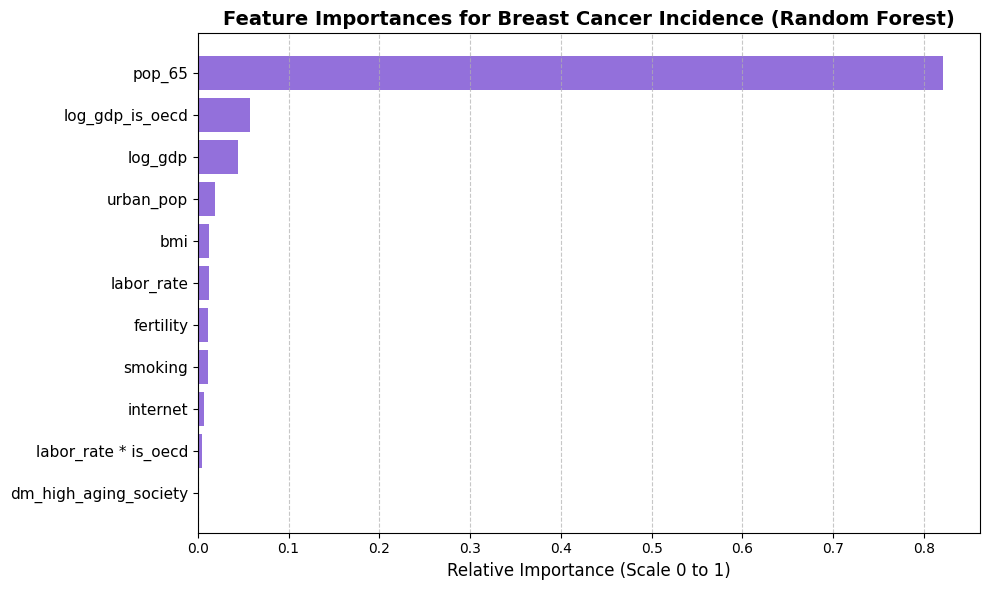

In [9]:
plt.figure(figsize=(10, 6))
plt.title('Feature Importances for Breast Cancer Incidence (Random Forest)', fontsize=14, fontweight='bold')
plt.barh(range(len(incidences)), importances[incidences], color='mediumpurple', align='center')
plt.yticks(range(len(incidences)), [features[i] for i in incidences], fontsize=11)
plt.xlabel('Relative Importance (Scale 0 to 1)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# oncovering non-linear Relationship:

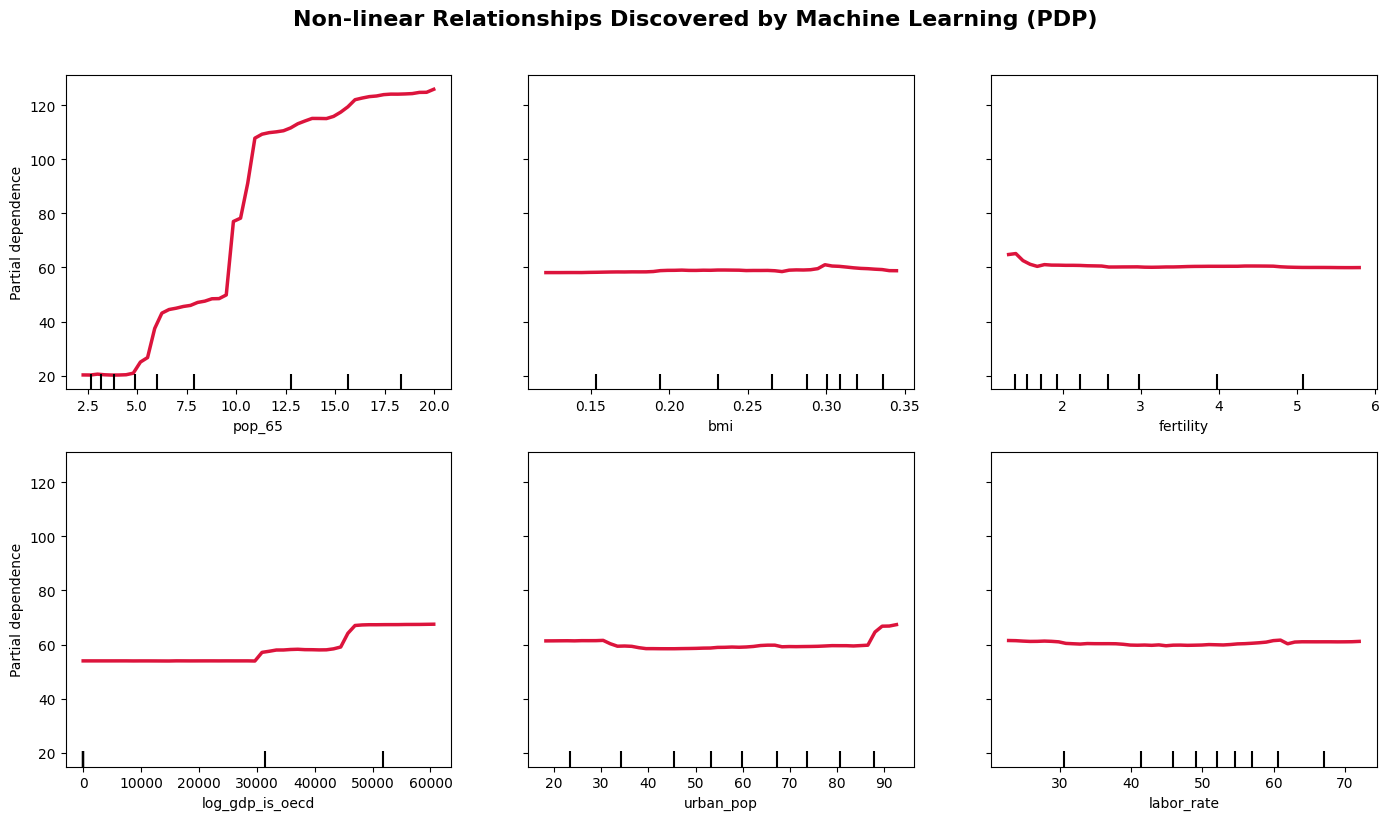

In [10]:
feature_lifestyle = ['pop_65', 'bmi','fertility']
feature_socioeconomic = ['log_gdp_is_oecd', 'urban_pop', 'labor_rate']
#feature_infrastructure= [ 'internet', 'smoking']
#feature_intraction = ['labor_rate * is_oecd', 'dm_high_aging_society']

fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(rf_incidence, x_train, 
feature_lifestyle+ feature_socioeconomic#+feature_infrastructure+ feature_intraction
,grid_resolution=50, ax=ax, line_kw={"color": "crimson", "linewidth": 2.5})
fig.suptitle('Non-linear Relationships Discovered by Machine Learning (PDP)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interactive 2DHeat map:

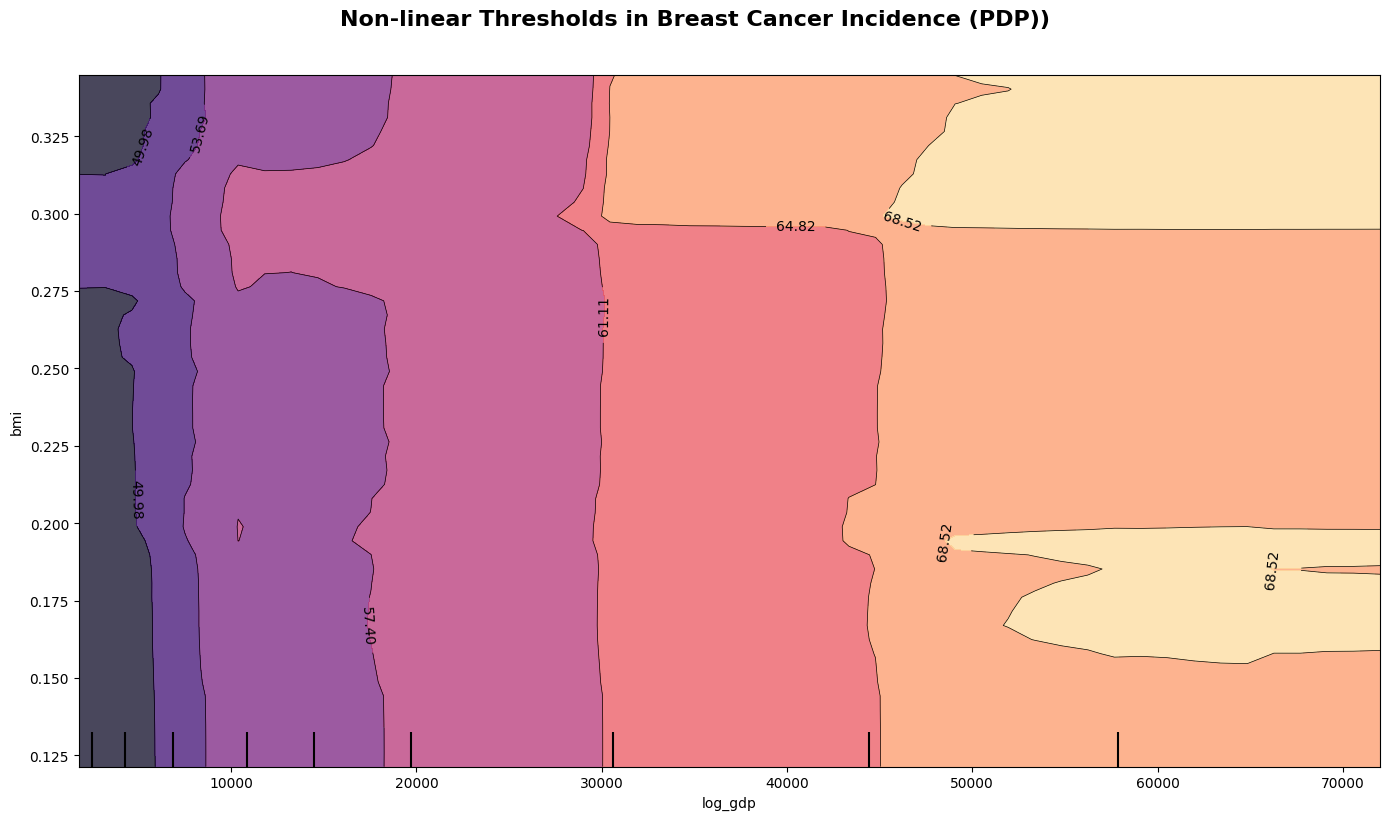

In [11]:
feature_lifestyle = [('log_gdp', 'bmi')]

fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train,feature_lifestyle,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})
fig.suptitle('Non-linear Thresholds in Breast Cancer Incidence (PDP))', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

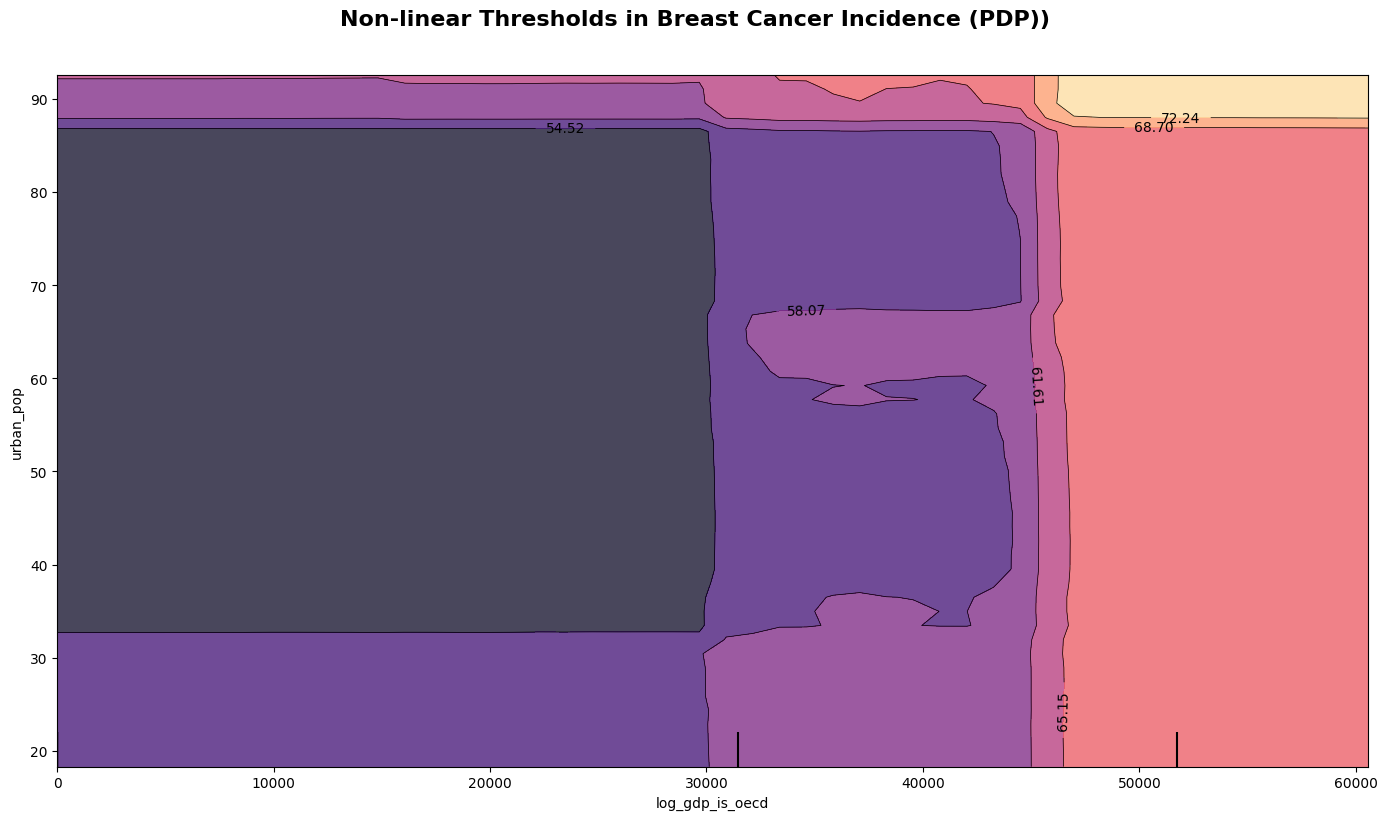

In [12]:
feature_socioeconomic = [('log_gdp_is_oecd', 'urban_pop')]
fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train,feature_socioeconomic,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})
fig.suptitle('Non-linear Thresholds in Breast Cancer Incidence (PDP))', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

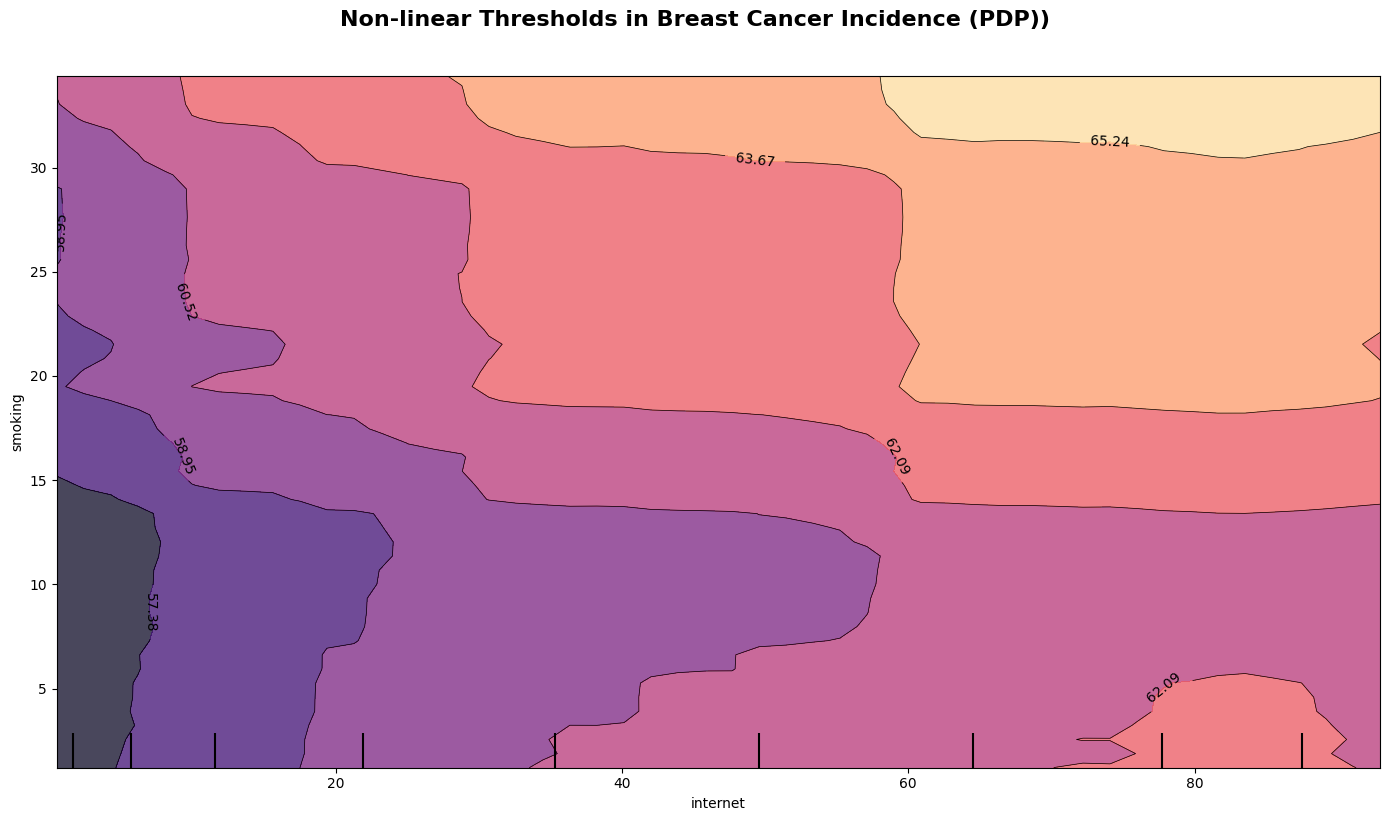

In [13]:
feature_infrastructure= [ ('internet', 'smoking') ]

fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train,feature_infrastructure,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})
fig.suptitle('Non-linear Thresholds in Breast Cancer Incidence (PDP))', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()